# Source Projection of Encoding Analysis - Layer Winner-Take-All Visualization

This notebook source-projects encoding analysis results and creates winner-take-all brain visualizations showing which neural network layer (layer1, layer2, layer3, avgpool) encodes best at each brain location.

## Analysis workflow:
1. **Data Loading**: Load encoding results (r_values) for multiple layers
2. **Source Projection**: Apply minimum norm estimation (MNE/dSPM) to project to source space
3. **Morphing**: Transform individual subject data to fsaverage space
4. **Layer Comparison**: Compute winner-take-all maps showing which layer has highest encoding
5. **Visualization**: Create brain plots showing spatial distribution of layer winners

**Date**: 2025-12-18

In [88]:
# Import required libraries
import sys
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import mne
from mne.minimum_norm import make_inverse_operator, apply_inverse

# Configure plotting
sns.set_context("poster")
plt.rcParams['svg.fonttype'] = 'none'

print("Libraries imported successfully!")

Libraries imported successfully!


## Configuration and Setup

In [98]:
# Subject and analysis configuration
subjects = [1]  # Add more subjects as needed: [1,2,3,4,5]
layers = ['avgpool']  # Layers to compare
model_name = 'resnet50_ecoset_crop'

# Source reconstruction method
method = "beamformer"  # Using pre-computed LCMV beamformer filters

# LCMV filter configuration
# Path to pre-computed beamformer filters
filters_dir = "/Users/atlas/avs/derivatives/pyavs/filters/saccade_55e86d0223d4c9b9"
# Which session's filter to use (1-10, or 'first' to use ses-01)
filter_session = 1  # Will use lcmv_filters_ses-01-lcmv.h5

# Morphing configuration
morph_to = 'as04'  
smooth = 5  # Smoothing parameter in mm

# Time window for averaging (None for time-resolved)
time_window = [0.0, 0.3]  # [tmin, tmax] in seconds, or None for full time-resolved

# Significance threshold for masking
significance_threshold = 0.05  # Minimum encoding strength

# Visualization parameters
views = ['lateral']  # Brain views to plot
surface = 'inflated'  # Surface type: 'inflated', 'pial', 'white'

# ============================================================================
# Data paths - SSH MOUNTS
# ============================================================================

# Base directories
avs_dir = "/Users/atlas/avs"
share_dir = "/Users/atlas/share_psulewski/psulewski"

# Encoding results path (SSH mount)
encoding_dir = f"{share_dir}/pyavs/encoding"

# FreeSurfer subjects directory (SSH mount)
subjects_dir = f"{avs_dir}/rawdir/"

# Template raw file for channel info (SSH mount)
template_raw_path = f"{avs_dir}/rawdir/as01a/as01ad.fif"

# Subject ID to FreeSurfer name mapping
SUBJECT_FS_MAPPING = {
    1: 'as01',
    2: 'as02',
    3: 'as03',
    4: 'as04',
    5: 'as05',
}

# Layer colors for visualization
LAYER_COLORS = {
    'layer1': [0.8, 0.2, 0.2],    # Red
    'layer2': [0.2, 0.8, 0.2],    # Green
    'layer3': [0.2, 0.2, 0.8],    # Blue
    'avgpool': [0.9, 0.9, 0.2],   # Yellow
    'non_sig': [0.5, 0.5, 0.5]    # Gray
}

print(f"Analysis configuration:")
print(f"- Subjects: {subjects}")
print(f"- Model: {model_name}")
print(f"- Layers: {layers}")
print(f"- Method: {method}")
print(f"- Filter session: {filter_session}")
print(f"- Morph to: {morph_to}")
if time_window:
    print(f"- Time window: {time_window[0]}-{time_window[1]} seconds")
else:
    print(f"- Time-resolved analysis")
print(f"\nPaths (SSH mounts):")
print(f"- Encoding dir: {encoding_dir}")
print(f"- Filters dir: {filters_dir}")
print(f"- Subjects dir: {subjects_dir}")
print(f"- Template raw: {template_raw_path}")

Analysis configuration:
- Subjects: [1]
- Model: resnet50_ecoset_crop
- Layers: ['avgpool']
- Method: beamformer
- Filter session: 1
- Morph to: as04
- Time window: 0.0-0.3 seconds

Paths (SSH mounts):
- Encoding dir: /Users/atlas/share_psulewski/psulewski/pyavs/encoding
- Filters dir: /Users/atlas/avs/derivatives/pyavs/filters/saccade_55e86d0223d4c9b9
- Subjects dir: /Users/atlas/avs/rawdir/
- Template raw: /Users/atlas/avs/rawdir/as01a/as01ad.fif


## Function Definitions

In [90]:
# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_encoding_results_multi_layer(subject_id, layers, model_name, encoding_dir):
    """
    Load encoding results for multiple layers.
    
    Parameters
    ----------
    subject_id : int
        Subject ID
    layers : list
        Layer names
    model_name : str
        Model name
    encoding_dir : str
        Base encoding directory (e.g., /Users/atlas/share_psulewski/psulewski/pyavs/encoding)
    
    Returns dict: {layer_name: {'r_values': array, 'times': array, 'metadata': dict}}
    """
    print(f"\nLoading encoding results for subject {subject_id}")
    print(f"Model: {model_name}")
    print(f"Layers: {layers}")
    print("-" * 60)
    
    layer_results = {}
    reference_times = None
    reference_n_channels = None
    
    for layer in layers:
        # Construct path to NPZ file
        # Files are in: encoding_dir/sub-XX/model-{model}_layer-{layer}_encoding_results.npz
        subject_dir = Path(encoding_dir) / f"sub-{subject_id:02d}"
        npz_filename = f"model-{model_name}_layer-{layer}_encoding_results.npz"
        npz_path = subject_dir / npz_filename
        
        if not npz_path.exists():
            raise FileNotFoundError(
                f"Encoding results not found: {npz_path}\n"
                f"Looking in: {subject_dir}"
            )
        
        # Load NPZ file
        print(f"  Loading {layer}: {npz_path.name}")
        results = np.load(str(npz_path), allow_pickle=True)
        
        r_values = results['r_values']
        times = results['times']
        n_channels, n_times = r_values.shape
        print(f"    Shape: {n_channels} channels × {n_times} timepoints")
        
        # Validate consistency across layers
        if reference_times is None:
            reference_times = times
            reference_n_channels = n_channels
        else:
            if n_channels != reference_n_channels:
                raise ValueError(f"Channel count mismatch for {layer}")
            if not np.allclose(times, reference_times):
                raise ValueError(f"Time array mismatch for {layer}")
        
        metadata = {
            'subject_id': int(results.get('subject_id', subject_id)),
            'model_name': str(results.get('model_name', model_name)),
            'layer': str(results.get('layer', layer))
        }
        
        layer_results[layer] = {
            'r_values': r_values,
            'times': times,
            'metadata': metadata
        }
    
    print(f"\nSuccessfully loaded {len(layer_results)} layers")
    print(f"Time range: {reference_times[0]:.3f} to {reference_times[-1]:.3f} seconds")
    
    return layer_results


def create_grad_info(template_raw_path):
    """
    Create MNE Info object for gradiometer channels.
    
    Note: The sampling frequency will be set automatically when creating the Evoked object
    based on the times array.
    """
    print(f"\nCreating Info for gradiometer channels")
    
    raw = mne.io.read_raw_fif(template_raw_path, preload=False, verbose=False)
    picks_grad = mne.pick_types(raw.info, meg='grad', exclude='bads')
    
    if len(picks_grad) == 0:
        raise ValueError("No gradiometer channels found")
    
    info_grad = mne.pick_info(raw.info, picks_grad)
    
    print(f"  Created Info with {len(info_grad['ch_names'])} channels")
    print(f"  Original sfreq: {info_grad['sfreq']} Hz (will be overridden by times array)")
    
    return info_grad


def create_evoked_from_r_values(r_values, times, info):
    """
    Create MNE Evoked object from encoding r_values.
    
    The sampling frequency is automatically inferred from the times array.
    """
    # MNE will automatically infer sfreq from the times array
    evoked = mne.EvokedArray(r_values, info, tmin=times[0], comment='encoding')
    return evoked

In [116]:
# ============================================================================
# SOURCE RECONSTRUCTION FUNCTIONS  
# ============================================================================

def load_lcmv_filter(subject_id, filter_session, filters_dir):
    """
    Load pre-computed LCMV beamformer filter.
    
    Parameters
    ----------
    subject_id : int
        Subject ID
    filter_session : int
        Session number (1-10)
    filters_dir : str
        Path to filters directory
    
    Returns
    -------
    mne.beamformer.Beamformer
        Pre-computed LCMV filter
    """
    print(f"\nLoading LCMV filter...")
    
    # Construct path to filter file
    subject_dir = Path(filters_dir) / f"sub-{subject_id:02d}"
    filter_filename = f"lcmv_filters_ses-{filter_session:02d}-lcmv.h5"
    filter_path = subject_dir / filter_filename
    
    if not filter_path.exists():
        raise FileNotFoundError(
            f"LCMV filter not found: {filter_path}\n"
            f"Looking in: {subject_dir}"
        )
    
    # Load the beamformer filter
    lcmv_filter = mne.beamformer.read_beamformer(str(filter_path))
    
    print(f"  Loaded filter: {filter_filename}")
    print(f"  Filter has {lcmv_filter['n_sources']} sources")
    
    return lcmv_filter


def apply_lcmv_to_encoding(evoked, lcmv_filter):
    """
    Apply LCMV beamformer to encoding data.
    
    Parameters
    ----------
    evoked : mne.EvokedArray
        Evoked object containing encoding r_values
    lcmv_filter : mne.beamformer.Beamformer
        Pre-computed LCMV filter
    
    Returns
    -------
    mne.SourceEstimate
        Source estimate with shape (n_vertices, n_times)
    """
    print(f"  Applying LCMV beamformer...")
    
    # Apply the beamformer filter
    stc = mne.beamformer.apply_lcmv(evoked, lcmv_filter)
    
    print(f"    Source estimate: {stc.data.shape[0]} vertices × {stc.data.shape[1]} timepoints")
    
    return stc


def morph_stc_to_fsaverage(stc, subject_from, subjects_dir, subject_to='fsaverage5', spacing=5, smooth=5):
    """Morph source estimate to fsaverage space."""
    print(f"  Morphing from {subject_from} to {subject_to}...")
    
    morph = mne.compute_source_morph(
        stc,
        subject_from=subject_from,
        subject_to=subject_to,
        subjects_dir=subjects_dir,
        spacing=spacing,
        smooth=smooth,
        verbose=False
    )
    
    stc_morphed = morph.apply(stc)
    
    print(f"    Morphed: {stc_morphed.data.shape[0]} vertices")
    
    return stc_morphed

In [92]:
# ============================================================================
# LAYER COMPARISON FUNCTIONS
# ============================================================================

def compute_layer_winners(layer_stcs, layers, time_window=None):
    """Compute winner-take-all layer map."""
    print(f"\nComputing layer winners")
    
    # Stack layer data: (n_layers, n_vertices, n_times)
    layer_data = np.stack([layer_stcs[layer].data for layer in layers], axis=0)
    print(f"  Stacked data shape: {layer_data.shape}")
    
    times = layer_stcs[layers[0]].times
    
    # Apply time window if specified
    if time_window is not None:
        tmin, tmax = time_window
        time_mask = (times >= tmin) & (times <= tmax)
        layer_data_window = layer_data[:, :, time_mask]
        print(f"  Time window: {tmin} to {tmax} seconds ({time_mask.sum()} timepoints)")
        
        # Average over time window
        layer_data_avg = np.mean(layer_data_window, axis=2)
        winner_layer_idx = np.argmax(layer_data_avg, axis=0)
        winner_strength = np.max(layer_data_avg, axis=0)
    else:
        # Time-resolved winners
        print(f"  Computing time-resolved winners")
        winner_layer_idx = np.argmax(layer_data, axis=0)
        winner_strength = np.max(layer_data, axis=0)
    
    print(f"  Winner shape: {winner_layer_idx.shape}")
    
    return winner_layer_idx, winner_strength, layer_data


def apply_significance_mask(winner_layer_idx, winner_strength, threshold=0.05):
    """Mask vertices where encoding is below threshold."""
    print(f"\nApplying significance mask (threshold: {threshold})")
    
    winner_masked = winner_layer_idx.copy()
    mask = winner_strength < threshold
    winner_masked[mask] = -1
    
    n_masked = mask.sum()
    n_total = mask.size
    pct_masked = 100 * n_masked / n_total
    
    print(f"  Masked {n_masked}/{n_total} ({pct_masked:.1f}%) vertices")
    
    return winner_masked


def average_stcs_across_subjects(subject_stcs, layers):
    """Average source estimates across subjects."""
    print(f"\nAveraging source estimates across {len(subject_stcs)} subjects")
    
    layer_stcs_avg = {}
    
    for layer in layers:
        stcs = [subject_stcs[subj][layer] for subj in subject_stcs.keys()]
        data_array = np.stack([stc.data for stc in stcs], axis=0)
        data_avg = np.mean(data_array, axis=0)
        
        stc_avg = stcs[0].copy()
        stc_avg.data = data_avg
        layer_stcs_avg[layer] = stc_avg
        
        print(f"  {layer}: averaged {len(stcs)} subjects")
    
    return layer_stcs_avg

In [93]:
# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def create_layer_colormap(layer_names):
    """Create discrete colormap for layer visualization."""
    colors = []
    colors.append(LAYER_COLORS['non_sig'])  # Gray for non-significant
    
    for layer in layer_names:
        if layer in LAYER_COLORS:
            colors.append(LAYER_COLORS[layer])
        else:
            colors.append([0.7, 0.7, 0.7])
    
    cmap = mcolors.ListedColormap(colors)
    return cmap


def plot_layer_winner_brain(winner_layer_idx, winner_strength, stc_template, layer_names,
                            output_dir, subject='fsaverage5', subjects_dir=None,
                            views=['lateral', 'medial'], surface='inflated', time_label='avg'):
    """Create brain plots showing layer winners."""
    print(f"\nCreating brain visualizations")
    os.makedirs(output_dir, exist_ok=True)
    
    # Plot 1: Layer winner map (categorical)
    print(f"  Creating layer winner map...")
    stc_winner = stc_template.copy()
    stc_winner.data = winner_layer_idx[:, np.newaxis]
    
    cmap = create_layer_colormap(layer_names)
    
    for view in views:
        try:
            brain = stc_winner.plot(
                subject=subject,
                subjects_dir=subjects_dir,
                hemi='both',
                views=view,
                initial_time=0,
                time_viewer=False,
                colorbar=False,
                background='white',
                surface=surface,
                size=(800, 600),
                clim=dict(kind='value', lims=[-1, len(layer_names)/2, len(layer_names)-1]),
                colormap=cmap
            )
            
            fname = f"layer_winner_map_{view}_{time_label}"
            fpath = os.path.join(output_dir, fname + '.png')
            brain.save_image(fpath)
            print(f"    Saved: {fname}.png")
            brain.close()
        except Exception as e:
            print(f"    Error plotting {view}: {e}")
    
    # Plot 2: Encoding strength map (continuous)
    print(f"  Creating encoding strength map...")
    stc_strength = stc_template.copy()
    stc_strength.data = winner_strength[:, np.newaxis]
    
    for view in views:
        try:
            brain = stc_strength.plot(
                subject=subject,
                subjects_dir=subjects_dir,
                hemi='both',
                views=view,
                initial_time=0,
                time_viewer=False,
                colorbar=True,
                background='white',
                surface=surface,
                size=(800, 600),
                colormap='hot',
                clim=dict(kind='value', pos_lims=[0.05, 0.1, 0.2])
            )
            
            fname = f"encoding_strength_map_{view}_{time_label}"
            fpath = os.path.join(output_dir, fname + '.png')
            brain.save_image(fpath)
            print(f"    Saved: {fname}.png")
            brain.close()
        except Exception as e:
            print(f"    Error plotting {view}: {e}")


def plot_individual_layer_brains(layer_stcs, layers, output_dir, subject='fsaverage5',
                                 subjects_dir=None, views=['lateral', 'medial'],
                                 surface='inflated', time_window=None):
    """Create separate brain plots for each layer."""
    print(f"\n  Creating individual layer brain plots...")
    
    for layer in layers:
        stc = layer_stcs[layer].copy()
        
        # Average over time window if specified
        if time_window is not None:
            tmin, tmax = time_window
            times = stc.times
            time_mask = (times >= tmin) & (times <= tmax)
            stc.data = np.mean(stc.data[:, time_mask], axis=1, keepdims=True)
        
        for view in views:
            try:
                brain = stc.plot(
                    subject=subject,
                    subjects_dir=subjects_dir,
                    hemi='both',
                    views=view,
                    initial_time=0,
                    time_viewer=False,
                    colorbar=True,
                    background='white',
                    surface=surface,
                    size=(800, 600),
                    colormap='hot',
                )
                
                fname = f"{layer}_encoding_{view}"
                fpath = os.path.join(output_dir, fname + '.png')
                brain.save_image(fpath)
                print(f"    Saved: {fname}.png")
                #brain.close()
            except Exception as e:
                print(f"    Error plotting {layer} {view}: {e}")

print("All functions defined successfully!")

All functions defined successfully!


In [110]:
# ============================================================================
# SENSOR-LEVEL VISUALIZATION FUNCTIONS
# ============================================================================

def plot_sensor_level_encoding(layer_results, info_grad, layers, subject_id):
    """
    Create sensor-level visualizations of encoding data.
    
    Parameters
    ----------
    layer_results : dict
        Dictionary of encoding results per layer
    info_grad : mne.Info
        Info object with gradiometer channels
    layers : list
        List of layer names
    subject_id : int
        Subject ID for title
    """
    from scipy.ndimage import gaussian_filter1d
    
    print("\nCreating sensor-level visualizations...")
    
    n_layers = len(layers)
    fig, axes = plt.subplots(n_layers, 2, figsize=(16, 4*n_layers))
    
    if n_layers == 1:
        axes = axes.reshape(1, -1)
    
    for i, layer in enumerate(layers):
        r_values = layer_results[layer]['r_values']
        times = layer_results[layer]['times']
        
        # Create Evoked object for plotting
        evoked = mne.EvokedArray(r_values, info_grad, tmin=times[0], comment=layer)
        print(evoked.data)
        # # Smooth the data for visualization (5ms Gaussian)
        # sigma_ms = 5
        # sigma_samples = sigma_ms * (1000.0 / (times[1] - times[0])) / 1000.0
        # evoked_smoothed = evoked.copy()
        # evoked_smoothed.data = gaussian_filter1d(evoked.data, sigma=sigma_samples, axis=1)
        
        # Panel 1: Time series of top channels
        ax1 = axes[i, 0]
        
        # Find channels with highest peak encoding
        max_encoding = np.abs(evoked.data).max(axis=1)
        top_channels_idx = np.argsort(max_encoding)[-10:]  # Top 10 channels
        
        # make a evoked.plot() call to plot top channels
        evoked.plot(picks=top_channels_idx, axes=ax1, show=False, titles=f"Layer: {layer} - Top Channels", scalings={'grad': 1})
        ax1.set_title(f"Subject {subject_id:02d} - Layer: {layer} - Top Channels", fontsize=14)
    
    # Print summary statistics
    print(f"\n{'='*60}")
    print("SENSOR-LEVEL ENCODING SUMMARY")
    print("="*60)
    for layer in layers:
        r_values = layer_results[layer]['r_values']
        print(f"{layer:10s} - Mean: {np.mean(np.abs(r_values)):.4f}, "
              f"Max: {np.max(np.abs(r_values)):.4f}, "
              f"Channels > 0.1: {(np.abs(r_values).max(axis=1) > 0.1).sum()}/{r_values.shape[0]}")

print("Sensor-level visualization functions defined!")

Sensor-level visualization functions defined!


SENSOR-LEVEL QUALITY CHECK

Loading data for subject 1...

Loading encoding results for subject 1
Model: resnet50_ecoset_crop
Layers: ['avgpool']
------------------------------------------------------------
  Loading avgpool: model-resnet50_ecoset_crop_layer-avgpool_encoding_results.npz
    Shape: 204 channels × 351 timepoints

Successfully loaded 1 layers
Time range: -0.200 to 0.500 seconds

Creating Info for gradiometer channels


/var/folders/27/cgtzfw9j75bc116gkfsr71v00000gn/T/ipykernel_84217/2205384643.py:90: RuntimeWarning: This filename (/Users/atlas/avs/rawdir/as01a/as01ad.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(template_raw_path, preload=False, verbose=False)


  Created Info with 204 channels
  Original sfreq: 1000.0 Hz (will be overridden by times array)

Creating sensor-level visualizations...
[[ 0.00704446  0.00449734  0.00844986 ...  0.00818069 -0.00237724
  -0.00600049]
 [ 0.02142835  0.02702574  0.011177   ...  0.01626223  0.00841886
   0.0191584 ]
 [ 0.00606704  0.0203576   0.01938234 ...  0.00325481  0.00625728
   0.01859179]
 ...
 [ 0.0219838   0.01755189  0.01172865 ... -0.00463496 -0.0137936
  -0.00101966]
 [ 0.01369322  0.02243255  0.02573785 ...  0.0202269   0.02394937
   0.01367206]
 [ 0.01405545  0.01667738  0.00034443 ... -0.02306941 -0.01786667
  -0.00690646]]

SENSOR-LEVEL ENCODING SUMMARY
avgpool    - Mean: 0.0210, Max: 0.2566, Channels > 0.1: 50/204

Sensor-level check complete! If the plots look good, proceed to source projection.


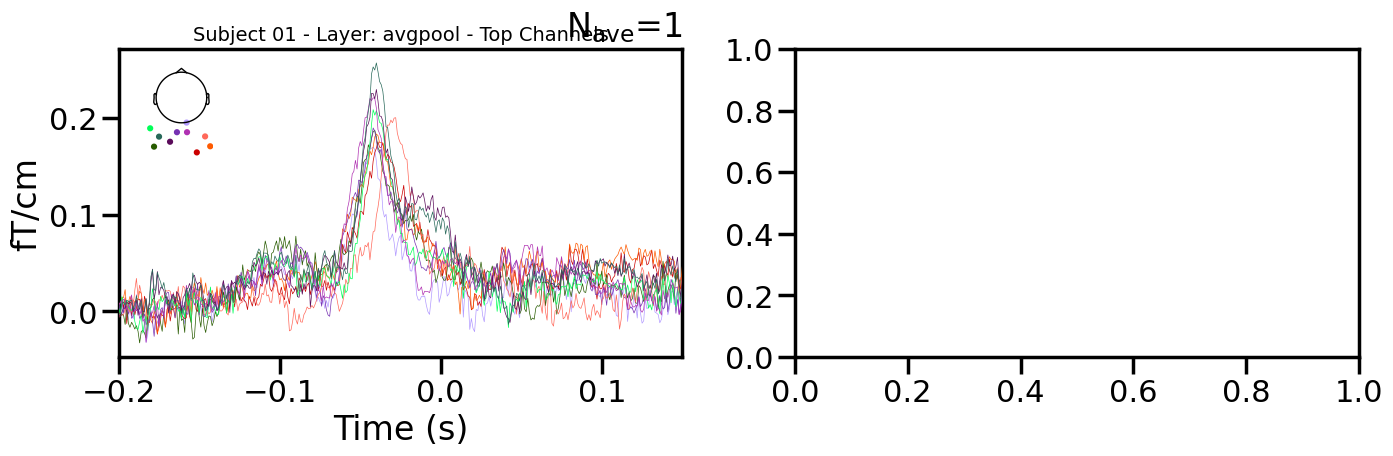

In [111]:
# Quick sensor-level check for first subject
print("="*80)
print("SENSOR-LEVEL QUALITY CHECK")
print("="*80)

# Load data for first subject
test_subject = subjects[0]
print(f"\nLoading data for subject {test_subject}...")

# Load encoding results
layer_results = load_encoding_results_multi_layer(
    test_subject, layers, model_name, encoding_dir
)

# Create Info object
info_grad = create_grad_info(template_raw_path)

# Visualize sensor-level encoding
plot_sensor_level_encoding(layer_results, info_grad, layers, test_subject)

print(f"\n{'='*80}")
print("Sensor-level check complete! If the plots look good, proceed to source projection.")
print("="*80)

## Sensor-Level Visualization (Quality Check)

Before source projection, let's visualize the encoding at the sensor level to verify data was loaded correctly.

## Processing: Load Encoding Results and Source Project

In [117]:
print("=" * 80)
print("PROCESSING SUBJECTS")
print("=" * 80)

subject_stcs = {}

for subject_id in subjects:
    print(f"\n{'='*80}")
    print(f"PROCESSING SUBJECT {subject_id}")
    print("="*80)
    
    try:
        # 1. Load encoding results for all layers
        layer_results = load_encoding_results_multi_layer(
            subject_id, layers, model_name, encoding_dir
        )
        
        # 2. Create MNE Info object for grad channels
        info_grad = create_grad_info(template_raw_path)
        
        # 3. Load pre-computed LCMV beamformer filter
        lcmv_filter = load_lcmv_filter(subject_id, filter_session, filters_dir)
        
        # 4. Source-project each layer using beamformer
        print(f"\n{'-'*60}")
        print(f"SOURCE PROJECTING LAYERS (BEAMFORMER)")
        print("-"*60)
        
        layer_stcs = {}
        for layer_name, layer_data in layer_results.items():
            print(f"\nProcessing layer: {layer_name}")
            
            # Create Evoked object
            evoked = create_evoked_from_r_values(
                layer_data['r_values'], layer_data['times'], info_grad
            )
            
            
         
            stc = apply_lcmv_to_encoding(evoked, lcmv_filter)
            
            layer_stcs[layer_name] = stc
        
        # 5. Morph to fsaverage
        print(f"\n{'-'*60}")
        print(f"MORPHING TO {morph_to.upper()}")
        print("-"*60)
        
        fs_subject = SUBJECT_FS_MAPPING[subject_id]
        layer_stcs_morphed = {}
        
        for layer_name, stc in layer_stcs.items():
            print(f"\nMorphing {layer_name}...")
            
            stc_morphed = morph_stc_to_fsaverage(
                stc,
                subject_from=fs_subject,
                subjects_dir=subjects_dir,
                subject_to=morph_to,
                spacing=5 if 'fsaverage5' in morph_to else None,
                smooth=smooth
            )
            
            layer_stcs_morphed[layer_name] = stc_morphed
        
        subject_stcs[subject_id] = layer_stcs_morphed
        
        print(f"\n{'='*80}")
        print(f"SUBJECT {subject_id} COMPLETE")
        print("="*80)
        
    except Exception as e:
        print(f"\nERROR processing subject {subject_id}: {e}")
        import traceback
        traceback.print_exc()

if len(subject_stcs) == 0:
    raise RuntimeError("No subjects processed successfully!")

print(f"\n{'='*80}")
print(f"ALL SUBJECTS PROCESSED: {len(subject_stcs)} subjects")
print("="*80)

PROCESSING SUBJECTS

PROCESSING SUBJECT 1

Loading encoding results for subject 1
Model: resnet50_ecoset_crop
Layers: ['avgpool']
------------------------------------------------------------
  Loading avgpool: model-resnet50_ecoset_crop_layer-avgpool_encoding_results.npz
    Shape: 204 channels × 351 timepoints

Successfully loaded 1 layers
Time range: -0.200 to 0.500 seconds

Creating Info for gradiometer channels


/var/folders/27/cgtzfw9j75bc116gkfsr71v00000gn/T/ipykernel_84217/2205384643.py:90: RuntimeWarning: This filename (/Users/atlas/avs/rawdir/as01a/as01ad.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(template_raw_path, preload=False, verbose=False)


  Created Info with 204 channels
  Original sfreq: 1000.0 Hz (will be overridden by times array)

Loading LCMV filter...
  Loaded filter: lcmv_filters_ses-01-lcmv.h5
  Filter has 8196 sources

------------------------------------------------------------
SOURCE PROJECTING LAYERS (BEAMFORMER)
------------------------------------------------------------

Processing layer: avgpool
  Applying LCMV beamformer...

ERROR processing subject 1: The spatial filter was computed with channel MEG0111 which is not present in the data. You should compute a new spatial filter restricted to the good data channels.


Traceback (most recent call last):
  File "/var/folders/27/cgtzfw9j75bc116gkfsr71v00000gn/T/ipykernel_84217/1081033434.py", line 40, in <module>
    stc = apply_lcmv_to_encoding(evoked, lcmv_filter)
  File "/var/folders/27/cgtzfw9j75bc116gkfsr71v00000gn/T/ipykernel_84217/2576365059.py", line 64, in apply_lcmv_to_encoding
    stc = mne.beamformer.apply_lcmv(evoked, lcmv_filter)
  File "<decorator-gen-530>", line 12, in apply_lcmv
  File "/Users/atlas/miniforge3/envs/mne/lib/python3.10/site-packages/mne/beamformer/_lcmv.py", line 363, in apply_lcmv
    sel = _check_channels_spatial_filter(evoked.ch_names, filters)
  File "/Users/atlas/miniforge3/envs/mne/lib/python3.10/site-packages/mne/utils/check.py", line 717, in _check_channels_spatial_filter
    raise ValueError(
ValueError: The spatial filter was computed with channel MEG0111 which is not present in the data. You should compute a new spatial filter restricted to the good data channels.


RuntimeError: No subjects processed successfully!

## Group-Level Analysis and Layer Winners

In [83]:
print("\n" + "="*80)
print("GROUP-LEVEL ANALYSIS")
print("="*80)

# Average across subjects (if multiple)
if len(subject_stcs) > 1:
    layer_stcs_avg = average_stcs_across_subjects(subject_stcs, layers)
else:
    layer_stcs_avg = subject_stcs[subjects[0]]
    print(f"\nSingle subject analysis (subject {subjects[0]})")

# Compute layer winners
winner_layer_idx, winner_strength, layer_data = compute_layer_winners(
    layer_stcs_avg, layers, time_window=time_window
)

# Apply significance masking
winner_layer_idx_masked = apply_significance_mask(
    winner_layer_idx, winner_strength, threshold=significance_threshold
)

# Print summary statistics
print(f"\nLayer Winner Summary:")
for i, layer in enumerate(layers):
    n_vertices = (winner_layer_idx_masked == i).sum()
    pct = 100 * n_vertices / winner_layer_idx_masked.size
    print(f"  {layer}: {n_vertices} vertices ({pct:.1f}%)")

n_non_sig = (winner_layer_idx_masked == -1).sum()
pct_non_sig = 100 * n_non_sig / winner_layer_idx_masked.size
print(f"  Non-significant: {n_non_sig} vertices ({pct_non_sig:.1f}%)")


GROUP-LEVEL ANALYSIS

Single subject analysis (subject 2)

Computing layer winners
  Stacked data shape: (1, 327684, 351)
  Time window: 0.0 to 0.3 seconds (151 timepoints)
  Winner shape: (327684,)

Applying significance mask (threshold: 0.05)
  Masked 57/327684 (0.0%) vertices

Layer Winner Summary:
  avgpool: 327627 vertices (100.0%)
  Non-significant: 57 vertices (0.0%)


## Visualization: Brain Plots

In [84]:
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Determine output directory
# Save locally in the encoding directory on the share mount
output_dir = os.path.join(encoding_dir, 'source_encoding_visualizations')

# Alternative: Save in local directory
# output_dir = os.path.expanduser("~/Desktop/encoding_source_plots")

print(f"\nOutput directory: {output_dir}")
os.makedirs(output_dir, exist_ok=True)

time_label = 'avg' if time_window is not None else 'timeresolved'

# Create winner and strength maps
# plot_layer_winner_brain(
#     winner_layer_idx_masked,
#     winner_strength,
#     layer_stcs_avg[layers[0]],
#     layers,
#     output_dir,
#     subject=morph_to,
#     subjects_dir=subjects_dir,
#     views=views,
#     surface=surface,
#     time_label=time_label
# )
print(layer_stcs_avg[layers[0]].data.mean(), )
# Create individual layer maps
plot_individual_layer_brains(
    layer_stcs_avg,
    layers,
    output_dir,
    subject=morph_to,
    subjects_dir=subjects_dir,
    views=views,
    surface=surface,
    time_window=time_window
)

print("\n" + "="*80)
print("PROCESSING COMPLETE!")
print("="*80)
print(f"\nResults saved to: {output_dir}")


CREATING VISUALIZATIONS

Output directory: /Users/atlas/share_psulewski/psulewski/pyavs/encoding/source_encoding_visualizations
1105784651117521.0

  Creating individual layer brain plots...
Using control points [4.54778898e+15 4.94249126e+15 5.61876725e+15]
    Saved: avgpool_encoding_lateral.png

PROCESSING COMPLETE!

Results saved to: /Users/atlas/share_psulewski/psulewski/pyavs/encoding/source_encoding_visualizations
